In [35]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import torchvision.datasets
from torchvision import transforms

In [2]:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [21]:
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize((224, 224), interpolation=torchvision.transforms.InterpolationMode.NEAREST),
])
test_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize((224, 224), interpolation=torchvision.transforms.InterpolationMode.NEAREST),
    # torchvision.transforms.cro
])

train_transform = torchvision.transforms.ToTensor()
test_transform = torchvision.transforms.ToTensor()

In [37]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [38]:
# pets_train = torchvision.datasets.OxfordIIITPet(root='./', split='trainval', target_types='category', download=True)
# pets_test = torchvision.datasets.OxfordIIITPet(root='./', split='test', target_types='category', download=True)

# pets_train = torchvision.datasets.OxfordIIITPet(root='./', split='trainval', target_types='category', download=True, transforms=train_transforms)
# pets_test = torchvision.datasets.OxfordIIITPet(root='./', split='test', target_types='category', download=True, transforms=test_transforms)

# pets_train = torchvision.datasets.OxfordIIITPet(root='./', split='trainval', target_types='category', download=True, transform=train_transform)
# pets_test = torchvision.datasets.OxfordIIITPet(root='./', split='test', target_types='category', download=True, transform=test_transform)

# pets_train = torchvision.datasets.OxfordIIITPet(root='./', split='trainval', target_types='category', download=True, transform=torchvision.transforms.ToTensor())
# pets_test = torchvision.datasets.OxfordIIITPet(root='./', split='test', target_types='category', download=True, transform=torchvision.transforms.ToTensor())

pets_train = torchvision.datasets.OxfordIIITPet(root='./', split='trainval', target_types='category', download=True, transforms=train_transforms)
pets_test = torchvision.datasets.OxfordIIITPet(root='./', split='test', target_types='category', download=True, transforms=test_transforms)

In [45]:
# pets_path_train = './OxfordPets/train'
# pets_path_test = './OxfordPets/test'
# pets_train_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_train, split='trainval', target_types='category', download=True)
# pets_test_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_test, split='test', target_types='category', download=True)

In [39]:
class_names = pets_train.classes

In [40]:
pets_train, pets_test

(Dataset OxfordIIITPet
     Number of datapoints: 3680
     Root location: ./
     Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 Dataset OxfordIIITPet
     Number of datapoints: 3669
     Root location: ./
     Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ))

In [42]:
# pets_test[0]

In [29]:
(train_pets_input, train_pets_target) = pets_train[20]
# plt.imshow(train_pets_input)
plt.imshow(train_pets_input.permute(1,2,0).numpy())
plt.title(class_names[train_pets_target])
plt.axis('off')
plt.show()

TypeError: Compose.__call__() takes 2 positional arguments but 3 were given

In [44]:
# train_pets_input

In [32]:
len(pets_train), len(pets_test)

(3680, 3669)

In [16]:
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [45]:
batch_size = 3
num_workers = 8

train_dataloader = torch.utils.data.DataLoader(dataset=pets_train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_dataloader = torch.utils.data.DataLoader(dataset=pets_test, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# train_dataloader = torch.utils.data.DataLoader(dataset=pets_train, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)
# test_dataloader = torch.utils.data.DataLoader(dataset=pets_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

In [47]:
len(train_dataloader), len(test_dataloader)

(1227, 1223)

In [51]:
# Create a dataset wrapper that allows us to perform custom image augmentations
# on both the target and label (segmentation mask) images.
#
# These custom image augmentations are needed since we want to perform
# transforms such as:
# 1. Random horizontal flip
# 2. Image resize
#
# and these operations need to be applied consistently to both the input
# image as well as the segmentation mask.
class OxfordIIITPetsAugmented(torchvision.datasets.OxfordIIITPet):
    def __init__(
        self,
        root: str,
        split: str,
        target_types="segmentation",
        download=False,
        pre_transform=None,
        post_transform=None,
        pre_target_transform=None,
        post_target_transform=None,
        common_transform=None,
    ):
        super().__init__(
            root=root,
            split=split,
            target_types=target_types,
            download=download,
            transform=pre_transform,
            target_transform=pre_target_transform,
        )
        self.post_transform = post_transform
        self.post_target_transform = post_target_transform
        self.common_transform = common_transform

    def __len__(self):
        return super().__len__()

    def __getitem__(self, idx):
        (input, target) = super().__getitem__(idx)
        
        # Common transforms are performed on both the input and the labels
        # by creating a 4 channel image and running the transform on both.
        # Then the segmentation mask (4th channel) is separated out.
        if self.common_transform is not None:
            both = torch.cat([input, target], dim=0)
            both = self.common_transform(both)
            (input, target) = torch.split(both, 3, dim=0)
        # end if
        
        if self.post_transform is not None:
            input = self.post_transform(input)
        if self.post_target_transform is not None:
            target = self.post_target_transform(target)

        return (input, target)

In [52]:
import torchvision.transforms as T

In [53]:
def args_to_dict(**kwargs):
    return kwargs

transform_dict = args_to_dict(
    pre_transform=T.ToTensor(),
    pre_target_transform=T.ToTensor(),
    common_transform=T.Compose([
        # ToDevice(get_device()),
        T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
        # Random Horizontal Flip as data augmentation.
        T.RandomHorizontalFlip(p=0.5),
    ]),
    post_transform=T.Compose([
        # Color Jitter as data augmentation.
        T.ColorJitter(contrast=0.3),
    ]),
    post_target_transform=T.Compose([
        # T.Lambda(tensor_trimap),
    ]),
)

In [54]:
pets_train = OxfordIIITPetsAugmented(
    root=pets_path_train,
    split="trainval",
    target_types="segmentation",
    download=False,
    **transform_dict,
)

In [12]:
pets_train

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ./
    StandardTransform
Transform: ToTensor()

In [57]:
pets_test = OxfordIIITPetsAugmented(
    root=pets_path_test,
    split="test",
    target_types="segmentation",
    download=False,
    **transform_dict,
)

In [58]:
pets_train_loader = torch.utils.data.DataLoader(
    pets_train,
    batch_size=64,
    shuffle=True,
)

In [59]:
pets_test_loader = torch.utils.data.DataLoader(
    pets_test,
    batch_size=21,
    shuffle=True,
)

In [48]:
(train_pets_inputs, train_pets_targets) = next(iter(pets_train_loader))

NameError: name 'pets_train_loader' is not defined

TypeError: only integer tensors of a single element can be converted to an index

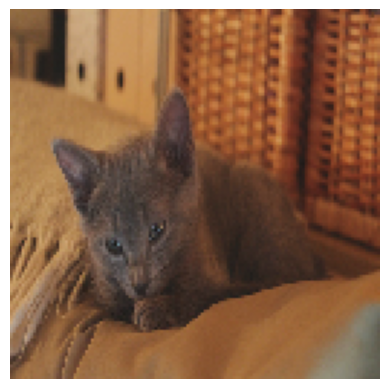

In [77]:
plt.imshow(train_pets_inputs[0].permute(1,2,0).numpy())
plt.axis('off')
plt.title(class_names[train_pets_targets[0]])
plt.show()

In [ ]:
# class_names[]

IndexError: list index out of range

In [14]:
def show_images(input_tensor, title=''):
    image = input_tensor.permute(1,2,0).numpy()
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.pause(0.01)

In [60]:
train_dataloader.dataset.transforms.co

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [49]:
(X_batch, y_batch) = next(iter(train_dataloader))
# for x_item, y_item in zip(X_batch, y_batch):
#     show_images(x_item, title=class_names[y_item])

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Program Files\Python312\Lib\site-packages\torch\utils\data\_utils\worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "c:\Program Files\Python312\Lib\site-packages\torchvision\datasets\oxford_iiit_pet.py", line 116, in __getitem__
    image, target = self.transforms(image, target)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: Compose.__call__() takes 2 positional arguments but 3 were given
